# Creditworthiness Prediction Using Machine Learning

**Objective:** Predict an individual's creditworthiness using past financial data.

**Algorithms:** Logistic Regression, Decision Tree, Random Forest

**Evaluation metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

> This project uses a simulated dataset for educational purposes. It is not intended for real lending decisions.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_STATE = 42

## 1. Load the dataset

In [2]:
df = pd.read_csv("dataset/credit_data.csv")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1000, 13)


,age,income,employment_years,loan_amount,debt,late_payments,credit_history_years,monthly_expenses,number_of_loans,employment_type,education,payment_history,creditworthy
0,24,148945.0,6,117815,38099.0,0,6,78387.0,5,Self-employed,Bachelor,Good,1
1,51,137347.0,1,102419,101128.0,3,14,79349.0,2,Salaried,Bachelor,Average,1
2,47,108447.0,12,139841,4233.0,0,17,41950.0,3,Salaried,Bachelor,Good,1
3,38,161598.0,14,144286,53567.0,4,19,75525.0,0,Salaried,Bachelor,Good,1
4,38,38779.0,20,107212,96116.0,1,8,43096.0,2,Contract,Master,NaN,1


## 2. Understand the data

In [3]:
display(df.info())
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1000 non-null   int64  
 1   income                992 non-null    float64
 2   employment_years      1000 non-null   int64  
 3   loan_amount           1000 non-null   int64  
 4   debt                  992 non-null    float64
 5   late_payments         1000 non-null   int64  
 6   credit_history_years  1000 non-null   int64  
 7   monthly_expenses      992 non-null    float64
 8   number_of_loans       1000 non-null   int64  
 9   employment_type       1000 non-null   object 
 10  education             1000 non-null   object 
 11  payment_history       992 non-null    object 
 12  creditworthy          1000 non-null   int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 101.7+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1000.0,NaN,NaN,NaN,40.612,11.546808,21.0,30.0,41.0,51.0,60.0
income,992.0,NaN,NaN,NaN,98380.753024,47275.082636,18199.0,57812.25,97969.5,139863.25,179797.0
employment_years,1000.0,NaN,NaN,NaN,12.168,7.948897,0.0,6.0,11.0,18.0,30.0
loan_amount,1000.0,NaN,NaN,NaN,77664.333,41472.434645,5082.0,40041.5,77456.5,113637.25,149887.0
debt,992.0,NaN,NaN,NaN,58817.555444,35024.86633,185.0,30741.0,57523.5,90196.25,119972.0
late_payments,1000.0,NaN,NaN,NaN,1.16,1.094348,0.0,0.0,1.0,2.0,6.0
credit_history_years,1000.0,NaN,NaN,NaN,8.707,5.381274,0.0,4.0,8.0,13.0,20.0
monthly_expenses,992.0,NaN,NaN,NaN,42547.733871,21262.626891,6023.0,24827.5,41590.5,60701.25,79961.0
number_of_loans,1000.0,NaN,NaN,NaN,3.0,2.016449,0.0,1.0,3.0,5.0,6.0
employment_type,1000,3,Salaried,578,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


income                  8
debt                    8
monthly_expenses        8
payment_history         8
age                     0
loan_amount             0
employment_years        0
credit_history_years    0
late_payments           0
number_of_loans         0
employment_type         0
education               0
creditworthy            0
dtype: int64

## 3. Data cleaning

In [4]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Ensure numeric columns are numeric
numeric_cols = [
    "age", "income", "employment_years", "loan_amount", "debt",
    "late_payments", "credit_history_years", "monthly_expenses",
    "number_of_loans"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Missing values will be imputed inside the ML preprocessing pipeline.
print("Shape after duplicate removal:", df.shape)

Shape after duplicate removal: (1000, 13)


## 4. Exploratory Data Analysis

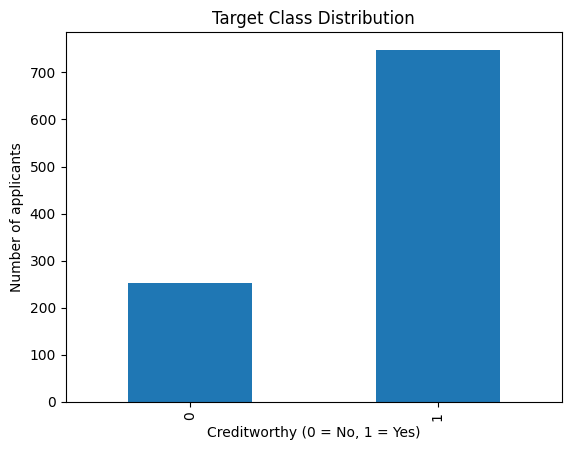

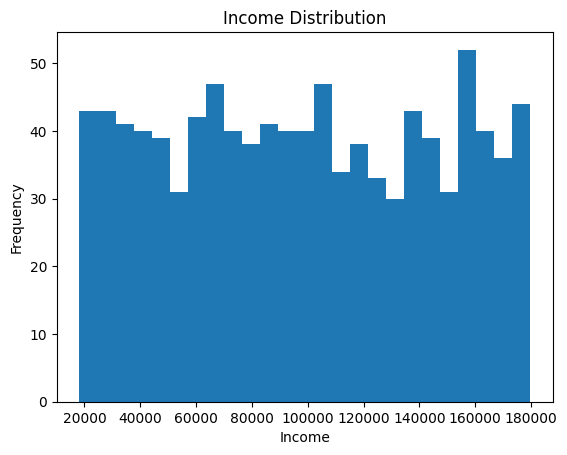

In [5]:
fig, ax = plt.subplots()
df["creditworthy"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("Creditworthy (0 = No, 1 = Yes)")
ax.set_ylabel("Number of applicants")
ax.set_title("Target Class Distribution")
plt.show()

fig, ax = plt.subplots()
df["income"].plot(kind="hist", bins=25, ax=ax)
ax.set_xlabel("Income")
ax.set_title("Income Distribution")
plt.show()

## 5. Feature engineering

In [6]:
# Debt-to-income ratio is a useful financial feature.
df["debt_to_income"] = df["debt"] / df["income"].replace(0, np.nan)

# Loan-to-income ratio
df["loan_to_income"] = df["loan_amount"] / df["income"].replace(0, np.nan)

# Approximate monthly savings
df["estimated_monthly_savings"] = df["income"] - df["monthly_expenses"]

display(df[[
    "income", "debt", "loan_amount", "debt_to_income",
    "loan_to_income", "estimated_monthly_savings", "creditworthy"
]].head())

,income,debt,loan_amount,debt_to_income,loan_to_income,estimated_monthly_savings,creditworthy
0,148945.0,38099.0,117815,0.255792,0.790997,70558.0,1
1,137347.0,101128.0,102419,0.736296,0.745695,57998.0,1
2,108447.0,4233.0,139841,0.039033,1.289487,66497.0,1
3,161598.0,53567.0,144286,0.331483,0.892870,86073.0,1
4,38779.0,96116.0,107212,2.478558,2.764692,-4317.0,1


## 6. Prepare features and target

In [7]:
X = df.drop(columns="creditworthy")
y = df["creditworthy"]

categorical_features = ["employment_type", "education", "payment_history"]
numeric_features = [c for c in X.columns if c not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


## 7. Train Logistic Regression

In [8]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 8. Train Decision Tree

In [9]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=5, random_state=RANDOM_STATE
    ))
])
tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 9. Train Random Forest

In [10]:
forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=3,
        random_state=RANDOM_STATE
    ))
])
forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 10. Evaluate all models

In [11]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

results = []
for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results).round(4)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.830,0.8580,0.9267,0.8910,0.8541
1,Decision Tree,0.800,0.8395,0.9067,0.8718,0.7574
2,Random Forest,0.825,0.8324,0.9600,0.8916,0.8285


## 11. Detailed evaluation

In [12]:
for name, model in models.items():
    pred = model.predict(X_test)
    print("=" * 60)
    print(name)
    print(classification_report(
        y_test, pred,
        target_names=["Not Creditworthy", "Creditworthy"],
        zero_division=0
    ))

Logistic Regression
                  precision    recall  f1-score   support

Not Creditworthy       0.71      0.54      0.61        50
    Creditworthy       0.86      0.93      0.89       150

        accuracy                           0.83       200
       macro avg       0.78      0.73      0.75       200
    weighted avg       0.82      0.83      0.82       200

Decision Tree
                  precision    recall  f1-score   support

Not Creditworthy       0.63      0.48      0.55        50
    Creditworthy       0.84      0.91      0.87       150

        accuracy                           0.80       200
       macro avg       0.74      0.69      0.71       200
    weighted avg       0.79      0.80      0.79       200

Random Forest
                  precision    recall  f1-score   support

Not Creditworthy       0.78      0.42      0.55        50
    Creditworthy       0.83      0.96      0.89       150

        accuracy                           0.82       200
       macro avg

## 12. Confusion matrix for Random Forest

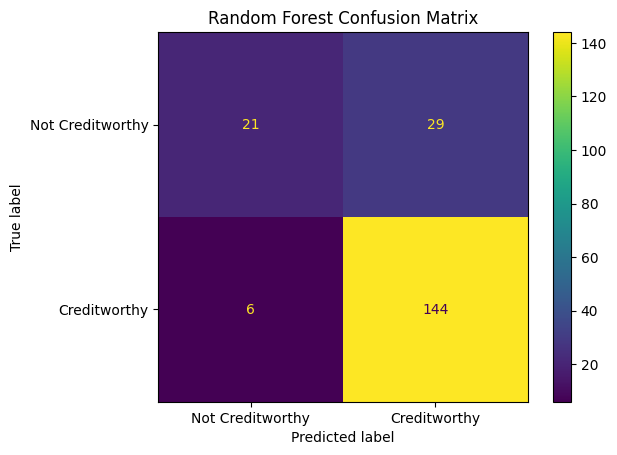

In [13]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_estimator(
    forest_model, X_test, y_test,
    display_labels=["Not Creditworthy", "Creditworthy"],
    ax=ax
)
ax.set_title("Random Forest Confusion Matrix")
plt.show()

## 13. ROC curves

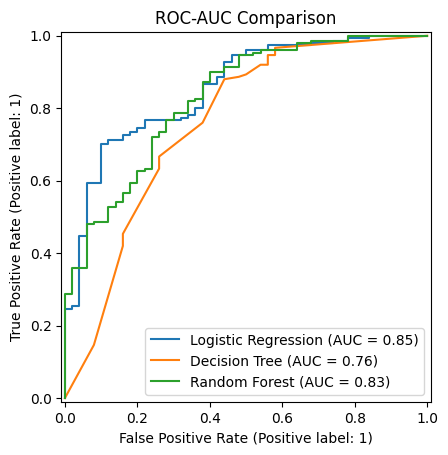

In [14]:
fig, ax = plt.subplots()
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.set_title("ROC-AUC Comparison")
plt.show()

## 14. Predict a new applicant

In [15]:
new_applicant = pd.DataFrame([{
    "age": 30,
    "income": 60000,
    "employment_years": 5,
    "loan_amount": 25000,
    "debt": 12000,
    "late_payments": 0,
    "credit_history_years": 6,
    "monthly_expenses": 25000,
    "number_of_loans": 1,
    "employment_type": "Salaried",
    "education": "Bachelor",
    "payment_history": "Good",
    "debt_to_income": 12000 / 60000,
    "loan_to_income": 25000 / 60000,
    "estimated_monthly_savings": 60000 - 25000
}])

prediction = forest_model.predict(new_applicant)[0]
probability = forest_model.predict_proba(new_applicant)[0, 1]

print("Prediction:", "Creditworthy" if prediction == 1 else "Not Creditworthy")
print(f"Model probability of Creditworthy: {probability:.2%}")

Prediction: Creditworthy
Model probability of Creditworthy: 82.18%


## 15. Conclusion

This project demonstrates an end-to-end binary classification workflow for predicting creditworthiness. Financial and payment-history features were cleaned and transformed, and engineered features such as debt-to-income and loan-to-income ratios were created. Logistic Regression, Decision Tree, and Random Forest models were trained and evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The model comparison table should be used to understand how the algorithms behave on the held-out test data. The project uses simulated data, so the results should not be interpreted as evidence of real-world lending performance.